In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as path_effects
import matplotlib.font_manager as fm
import matplotlib.patches as patches
from matplotlib import rcParams
from highlight_text import fig_text, ax_text
import matplotlib.colors as mcolors
from matplotlib import cm
from PIL import Image
import urllib
import os

df = pd.read_csv("predictions.csv", header = 0)

df1 = pd.read_csv('Loghi_SerieA.csv')
df = pd.merge(df, df1, on='team')

df

,team,M,xG.h,xGA.h,xG90.h,xGA90.h,xG.a,xGA.a,xG90.a,xGA90.a,Power Index,team_id
0,Milan,19,32.44,14.72,1.707368,0.774737,34.90,19.91,1.836842,1.047895,78.7,8564
1,Atalanta,19,35.30,26.35,1.857895,1.386842,33.42,20.25,1.758947,1.065789,72.6,8524
2,Bologna,19,22.79,24.47,1.199474,1.287895,22.76,33.58,1.197895,1.767368,56.1,9857
3,Cremonese,19,21.96,35.30,1.155789,1.857895,14.78,37.25,0.777895,1.960526,49.0,7801
4,Empoli,19,23.48,43.06,1.235789,2.266316,22.04,31.76,1.160000,1.671579,49.9,8534
5,Fiorentina,19,38.85,18.24,2.044737,0.960000,23.19,26.99,1.220526,1.420526,67.5,8535
6,Inter,19,50.86,16.57,2.676842,0.872105,39.53,23.31,2.080526,1.226842,82.3,8636
7,Juventus,19,31.38,15.13,1.651579,0.796316,29.45,25.31,1.550000,1.332105,70.0,9885
8,Lazio,19,33.40,24.22,1.757895,1.274737,25.89,25.88,1.362632,1.362105,69.2,8543
9,Lecce,19,23.27,33.44,1.224737,1.760000,16.27,35.69,0.856316,1.878421,50.7,9888


In [2]:
def prediction2(data, ax, team_home = "Inter", team_away = "Milan"):
    
    #constant
    average_xG_h = data['xG90.h'].sum()/20
    average_xGA_h = data['xGA90.h'].sum()/20
    average_xG_a = data['xG90.a'].sum()/20
    average_xGA_a = data['xGA90.a'].sum()/20
    
    # -- Filter the data from our DF
    team_df_h = data[data["team"] == team_home].reset_index(drop = True)
    team_df_a = data[data["team"] == team_away].reset_index(drop = True)
    
    home_attack = team_df_h["xG90.h"]/average_xG_h
    home_defense = team_df_a["xGA90.h"]/average_xGA_h
    away_attack = team_df_a["xG90.a"]/average_xG_a
    away_defense = team_df_a["xGA90.a"]/average_xGA_a
    
    projected_h_g = home_attack*away_defense*average_xG_h
    projected_a_g = away_attack*home_defense*average_xG_a
    
    if (team_df_h.at[0, "Power Index"] <= team_df_a.at[0, "Power Index"]):
        diff_pi = (team_df_a["Power Index"]-team_df_h["Power Index"])/200
        projected_h_g = projected_h_g*(1-diff_pi)
        projected_a_g = projected_a_g*(1+diff_pi)
        
    else:
        diff_pi = (team_df_h["Power Index"]-team_df_a["Power Index"])/200
        projected_h_g = projected_h_g*(1+diff_pi)
        projected_a_g = projected_a_g*(1-diff_pi)
        
    projected_tot_g = projected_h_g+projected_a_g
    
    h_goals = []
    a_goals = []
    
    table = np.zeros((7,7), float)
       
    h = [6, 5, 4, 3, 2, 1, 0]
    a = [0, 1, 2, 3, 4, 5, 6]
    
    for i in range (len(h)):
        h_goals = np.append(h_goals, (((projected_a_g**i)*np.exp(-projected_a_g))/math.factorial(i)).astype(float))
        
    for i in range (len(a)):
        a_goals = np.append(a_goals, (((projected_h_g**i)*np.exp(-projected_h_g))/math.factorial(i)).astype(float))
    
    for i in range (len(h)):
        for j in range (len(a)):
            table[i,j] = round(h_goals[i]*a_goals[j]*100, 2)
            
    [m,n] = np.shape(table)

    #Colour Map using Matrix
    ax.imshow(table, alpha=0.6, cmap="Blues", interpolation='nearest', origin="lower")    
    min_val, max_val, diff = 0., 7, 1    
    ax.set_xticks(np.arange(min_val, max_val))
    ax.set_yticks(np.arange(min_val, max_val))
    ax.set_xticklabels([0,1,2,3,4,5,6])
    ax.set_yticklabels([0,1,2,3,4,5,6])
    ax.set_xlim(min_val-diff/2, max_val-diff/2)
    ax.set_ylim(min_val-diff/2, max_val-diff/2)
    #ax.grid(which='major', axis='both', linestyle='-', color='black')
    
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True) 
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # Add axes legends
    ax.yaxis.set_label_text("{} goals".format(team_home), size = 10)
    ax.xaxis.set_label_text("{} goals".format(team_away), size = 10)
           
    win = 0
    draw = 0
    lose = 0

    for i in range(m):
        for j in range(n):
            c = table[i][j]
            ax.text(i, j, str(round(c,1))+"%", va='center', ha='center', size=8)
            if (i==j):
                draw = round(draw+c, 1)
            elif (i>j):
                lose = round(lose+c, 1)
            else:
                win = round(win+c, 1)
    
    ax.text(2.5, -1.6, s = "home win {}%    draw {}%    away win {}%".format(win, draw, lose), va='center', ha='center', size=10.5)
    
    return ax, team_home+' vs '+team_away, win, draw, lose

(<AxesSubplot:xlabel='Juventus goals', ylabel='Fiorentina goals'>,
 'Fiorentina vs Juventus',
 56.9,
 23.3,
 19.5)

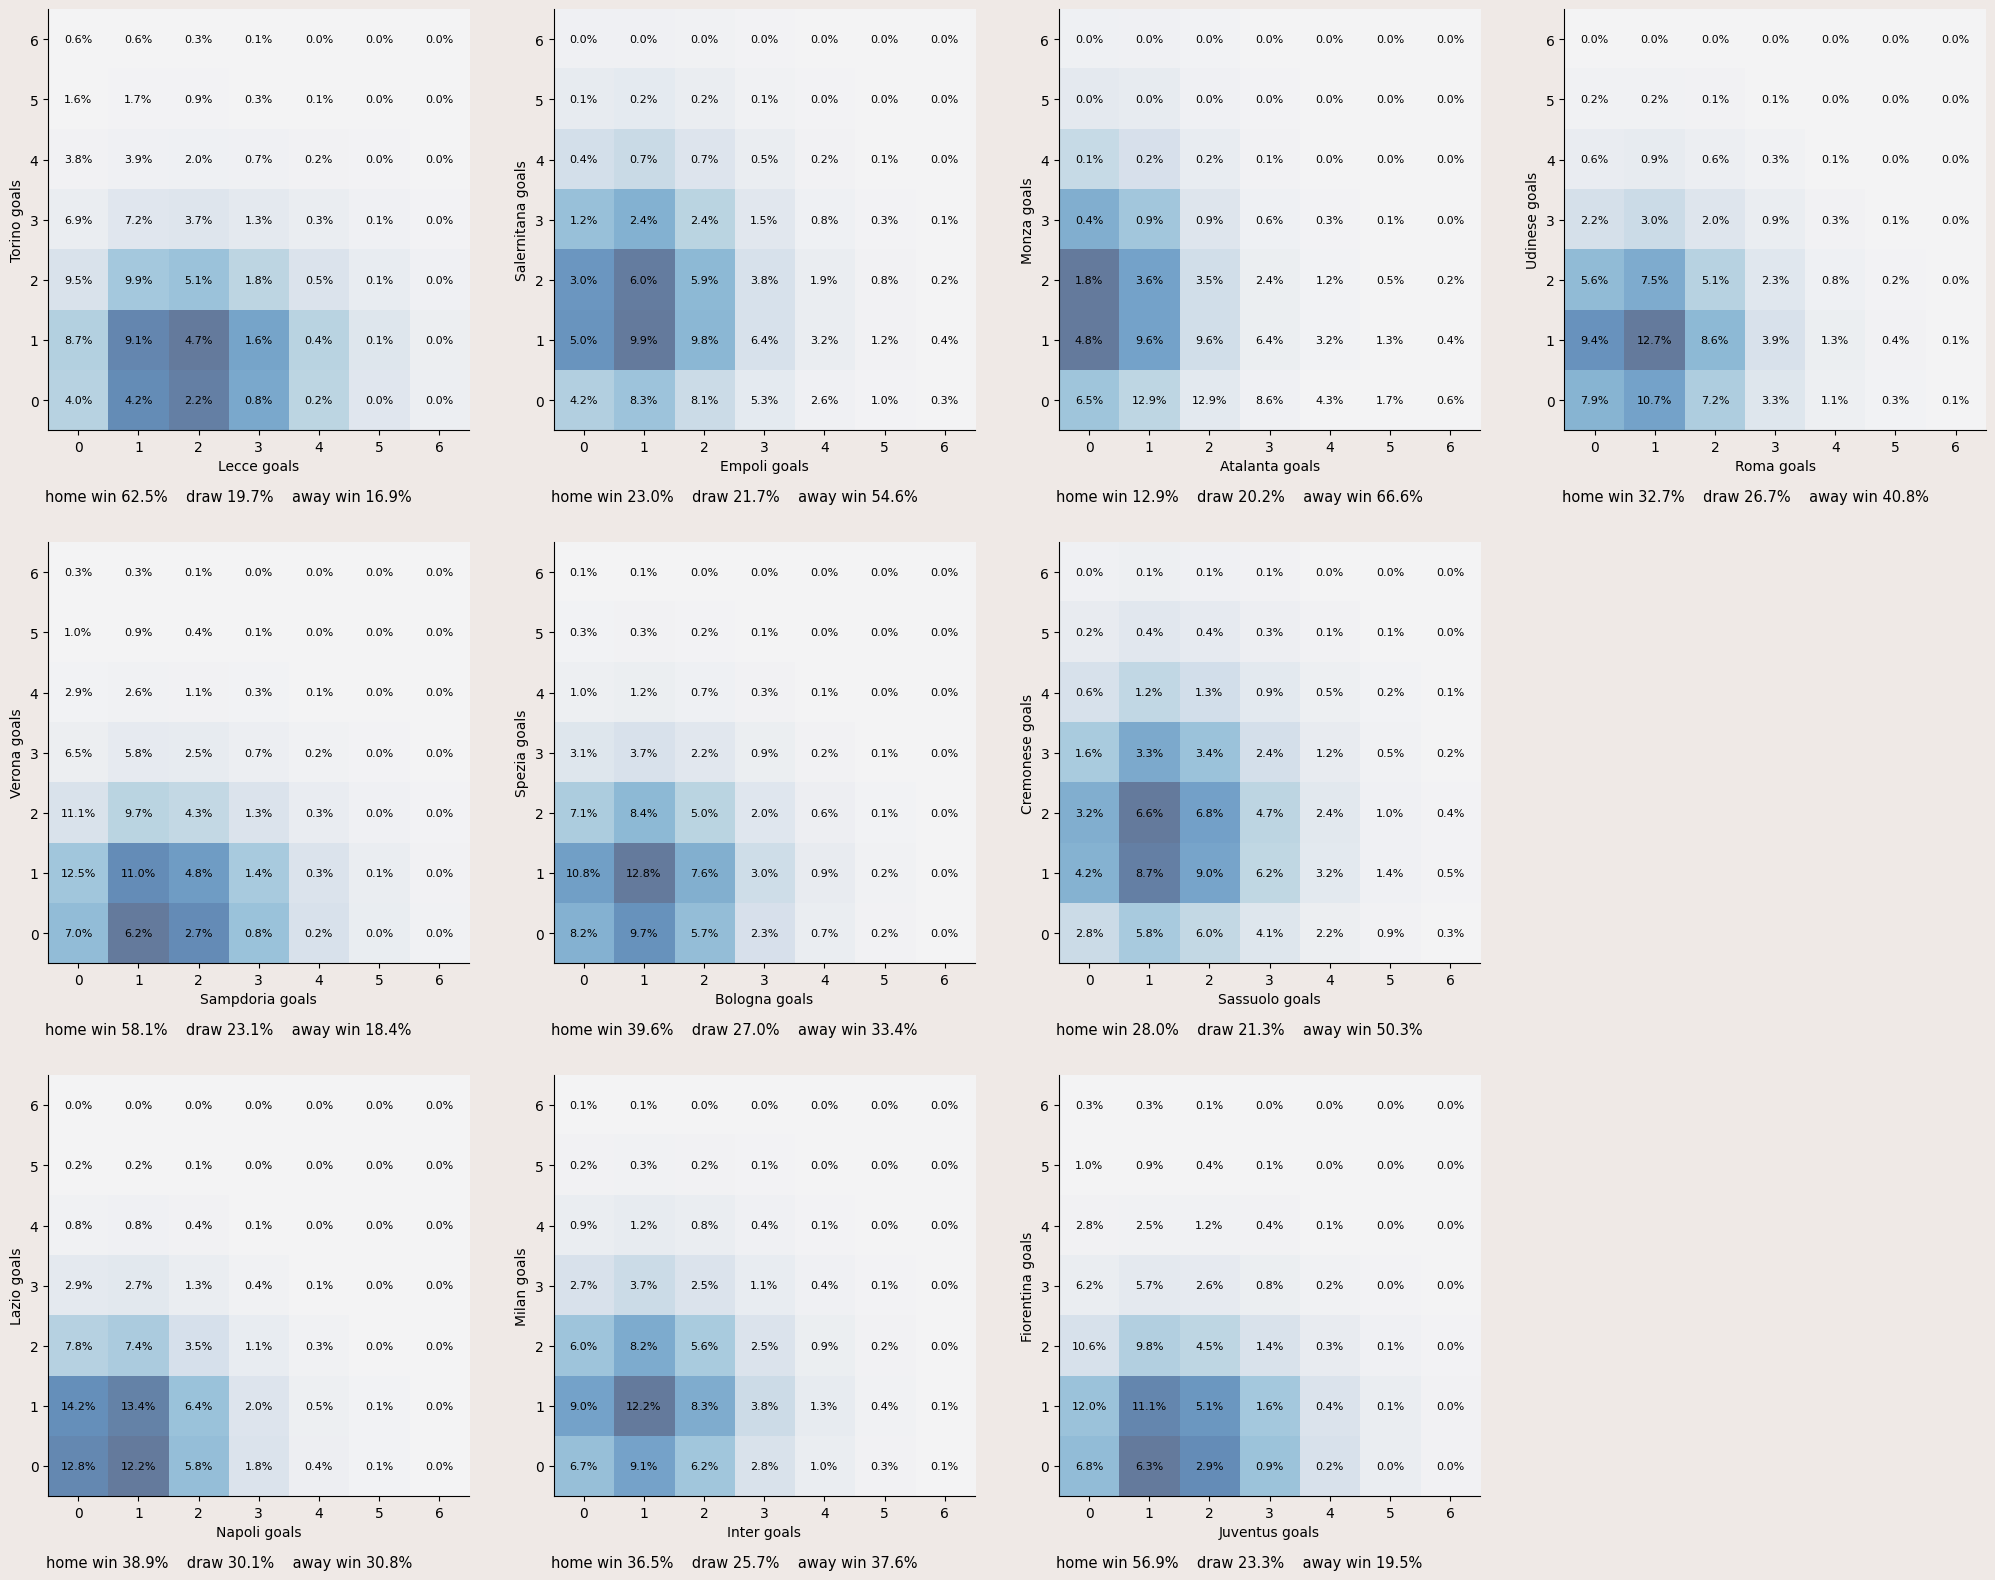

In [3]:
fig = plt.figure(figsize = (25, 20), dpi = 100, facecolor = "#EFE9E6")
gspec = gridspec.GridSpec(ncols=4, nrows=3, figure=fig, )

ax1 = plt.subplot(gspec[0,0], facecolor = "#EFE9E6")
prediction2(data = df, ax = ax1, team_home = "Torino", team_away = "Lecce")

ax2 = plt.subplot(gspec[0,1], facecolor = "#EFE9E6")
prediction2(data = df, ax = ax2, team_home = "Salernitana", team_away = "Empoli")

ax3 = plt.subplot(gspec[0,2], facecolor = "#EFE9E6")
prediction2(data = df, ax = ax3, team_home = "Monza", team_away = "Atalanta")

ax4 = plt.subplot(gspec[0,3], facecolor = "#EFE9E6")
prediction2(data = df, ax = ax4, team_home = "Udinese", team_away = "Roma")

ax5 = plt.subplot(gspec[1,0], facecolor = "#EFE9E6")
prediction2(data = df, ax = ax5, team_home = "Verona", team_away = "Sampdoria")

ax6 = plt.subplot(gspec[1,1], facecolor = "#EFE9E6")
prediction2(data = df, ax = ax6, team_home = "Spezia", team_away = "Bologna")

ax7 = plt.subplot(gspec[1,2], facecolor = "#EFE9E6")
prediction2(data = df, ax = ax7, team_home = "Cremonese", team_away = "Sassuolo")

ax8 = plt.subplot(gspec[2,0], facecolor = "#EFE9E6")
prediction2(data = df, ax = ax8, team_home = "Lazio", team_away = "Napoli")

ax9 = plt.subplot(gspec[2,1], facecolor = "#EFE9E6")
prediction2(data = df, ax = ax9, team_home = "Milan", team_away = "Inter")

ax10 = plt.subplot(gspec[2,2], facecolor = "#EFE9E6")
prediction2(data = df, ax = ax10, team_home = "Fiorentina", team_away = "Juventus")

In [3]:
def prediction(data, team_home = "Inter", team_away = "Milan"):
    
    #constant
    average_xG_h = data['xG90.h'].sum()/20
    average_xGA_h = data['xGA90.h'].sum()/20
    average_xG_a = data['xG90.a'].sum()/20
    average_xGA_a = data['xGA90.a'].sum()/20
    
    # -- Filter the data from our DF
    team_df_h = data[data["team"] == team_home].reset_index(drop = True)
    team_df_a = data[data["team"] == team_away].reset_index(drop = True)
    
    home_id = team_df_h.at[0, 'team_id']
    away_id = team_df_a.at[0, 'team_id']
    
    home_attack = team_df_h["xG90.h"]/average_xG_h
    home_defense = team_df_a["xGA90.h"]/average_xG_a
    away_attack = team_df_a["xG90.a"]/average_xG_a
    away_defense = team_df_a["xGA90.a"]/average_xG_h
    
    projected_h_g = home_attack*away_defense*average_xG_h
    projected_a_g = away_attack*home_defense*average_xG_a
    
    if (team_df_h.at[0, "Power Index"] <= team_df_a.at[0, "Power Index"]):
        diff_pi = (team_df_a["Power Index"]-team_df_h["Power Index"])/200
        projected_h_g = projected_h_g*(1-diff_pi)
        projected_a_g = projected_a_g*(1+diff_pi)
        
    else:
        diff_pi = (team_df_h["Power Index"]-team_df_a["Power Index"])/200
        projected_h_g = projected_h_g*(1+diff_pi)
        projected_a_g = projected_a_g*(1-diff_pi)
        
    projected_tot_g = projected_h_g+projected_a_g
    
    h_goals = []
    a_goals = []
    
    table = np.zeros((7,7), float)
       
    h = [6, 5, 4, 3, 2, 1, 0]
    a = [0, 1, 2, 3, 4, 5, 6]
    
    for i in range (len(h)):
        h_goals = np.append(h_goals, (((projected_a_g**i)*np.exp(-projected_a_g))/math.factorial(i)).astype(float))
        
    for i in range (len(a)):
        a_goals = np.append(a_goals, (((projected_h_g**i)*np.exp(-projected_h_g))/math.factorial(i)).astype(float))
    
    for i in range (len(h)):
        for j in range (len(a)):
            table[i,j] = h_goals[i]*a_goals[j]*100
            
    [m,n] = np.shape(table)
       
    win = 0
    draw = 0
    lose = 0

    for i in range(m):
        for j in range(n):
            c = table[i][j]
            #ax.text(i, j, str(round(c,1))+"%", va='center', ha='center', size=8)
            if (i==j):
                draw = round(draw+c, 1)
            elif (i>j):
                lose = round(lose+c, 1)
            else:
                win = round(win+c, 1)
                
    win = str(win)
    draw = str(draw)
    lose = str(lose)
                
    max_val = table[0][0]
    max_row = 0
    max_col = 0
    for i, row in enumerate(table):
        for j, idx in enumerate(row):
            if table[i][j] > max_val:
                max_val = table[i][j]
                max_row = j
                max_col = i
    result = str(max_row) + " - " + str(max_col)
    confidence = str(round(max_val, 1))
    
    return win, draw, lose, result, confidence, team_home, home_id, team_away, away_id

In [4]:
table = np.empty((10,5), dtype=object)
home_teams = []
home_ids = []
away_teams = []
away_ids = []

win,draw,lose,result,confidence,home_team,home_id,away_team,away_id = prediction(data=df, team_home="Lecce", 
                                                                                 team_away="Fiorentina")
home_teams.append(home_team)
home_ids.append(home_id)
away_teams.append(away_team)
away_ids.append(away_id)
table[0][0] = win
table[0][1] = draw
table[0][2] = lose
table[0][3] = result
table[0][4] = confidence

win,draw,lose,result,confidence,home_team,home_id,away_team,away_id = prediction(data=df, team_home="Sampdoria", 
                                                                                 team_away="Roma")
home_teams.append(home_team)
home_ids.append(home_id)
away_teams.append(away_team)
away_ids.append(away_id)
table[1][0] = win
table[1][1] = draw
table[1][2] = lose
table[1][3] = result
table[1][4] = confidence

win,draw,lose,result,confidence,home_team,home_id,away_team,away_id = prediction(data=df, team_home="Verona", 
                                                                                 team_away="Milan")
home_teams.append(home_team)
home_ids.append(home_id)
away_teams.append(away_team)
away_ids.append(away_id)
table[2][0] = win
table[2][1] = draw
table[2][2] = lose
table[2][3] = result
table[2][4] = confidence

win,draw,lose,result,confidence,home_team,home_id,away_team,away_id = prediction(data=df, team_home="Napoli", 
                                                                                 team_away="Bologna")
home_teams.append(home_team)
home_ids.append(home_id)
away_teams.append(away_team)
away_ids.append(away_id)
table[3][0] = win
table[3][1] = draw
table[3][2] = lose
table[3][3] = result
table[3][4] = confidence

win,draw,lose,result,confidence,home_team,home_id,away_team,away_id = prediction(data=df, team_home="Spezia", 
                                                                                 team_away="Cremonese")
home_teams.append(home_team)
home_ids.append(home_id)
away_teams.append(away_team)
away_ids.append(away_id)
table[4][0] = win
table[4][1] = draw
table[4][2] = lose
table[4][3] = result
table[4][4] = confidence

win,draw,lose,result,confidence,home_team,home_id,away_team,away_id = prediction(data=df, team_home="Lazio", 
                                                                                 team_away="Udinese")
home_teams.append(home_team)
home_ids.append(home_id)
away_teams.append(away_team)
away_ids.append(away_id)
table[5][0] = win
table[5][1] = draw
table[5][2] = lose
table[5][3] = result
table[5][4] = confidence

win,draw,lose,result,confidence,home_team,home_id,away_team,away_id = prediction(data=df, team_home="Inter", 
                                                                                 team_away="Salernitana")
home_teams.append(home_team)
home_ids.append(home_id)
away_teams.append(away_team)
away_ids.append(away_id)
table[6][0] = win
table[6][1] = draw
table[6][2] = lose
table[6][3] = result
table[6][4] = confidence

win,draw,lose,result,confidence,home_team,home_id,away_team,away_id = prediction(data=df, team_home="Atalanta", 
                                                                                 team_away="Sassuolo")
home_teams.append(home_team)
home_ids.append(home_id)
away_teams.append(away_team)
away_ids.append(away_id)
table[7][0] = win
table[7][1] = draw
table[7][2] = lose
table[7][3] = result
table[7][4] = confidence

win,draw,lose,result,confidence,home_team,home_id,away_team,away_id = prediction(data=df, team_home="Torino",
                                                                                 team_away="Juventus")
home_teams.append(home_team)
home_ids.append(home_id)
away_teams.append(away_team)
away_ids.append(away_id)
table[8][0] = win
table[8][1] = draw
table[8][2] = lose
table[8][3] = result
table[8][4] = confidence

win,draw,lose,result,confidence,home_team,home_id,away_team,away_id = prediction(data=df, team_home="Empoli", 
                                                                                 team_away="Monza")
home_teams.append(home_team)
home_ids.append(home_id)
away_teams.append(away_team)
away_ids.append(away_id)
table[9][0] = win
table[9][1] = draw
table[9][2] = lose
table[9][3] = result
table[9][4] = confidence

In [5]:
df2 = pd.DataFrame(table)
df2.loc[:,"home_team"] = home_teams[0:10]
df2.loc[:,"home_id"] = home_ids[0:10]
df2.loc[:,"away_team"] = away_teams[0:10]
df2.loc[:,"away_id"] = away_ids[0:10]

cols = ['HOME WIN %', 'DRAW %', 'AWAY WIN %', 'MOST PROBABLE RESULT', 'CONFIDENCE %', 
        'HOME TEAM', 'HOME ID', 'AWAY TEAM', 'AWAY ID']
df2.columns=cols[:]
df2

,HOME WIN %,DRAW %,AWAY WIN %,MOST PROBABLE RESULT,CONFIDENCE %,HOME TEAM,HOME ID,AWAY TEAM,AWAY ID
0,36.6,31.0,32.2,1 - 0,14.2,Lecce,9888,Fiorentina,8535
1,23.1,27.2,49.1,0 - 1,14.4,Sampdoria,9882,Roma,8686
2,27.6,30.1,42.2,0 - 1,15.1,Verona,9876,Milan,8564
3,65.3,18.4,15.2,2 - 1,9.7,Napoli,9875,Bologna,9857
4,46.5,25.8,27.3,1 - 1,12.3,Spezia,9881,Cremonese,7801
5,43.5,23.3,32.7,1 - 1,10.5,Lazio,8543,Udinese,8600
6,75.4,6.4,4.0,4 - 0,7.2,Inter,8636,Salernitana,6480
7,53.7,17.9,25.7,2 - 1,7.1,Atalanta,8524,Sassuolo,7943
8,47.0,27.2,25.5,1 - 0,13.4,Torino,9804,Juventus,9885
9,41.0,25.6,33.3,1 - 1,12.2,Empoli,8534,Monza,6504


In [6]:
gradient = [
    '#efe9e6',
    '#e9e1dd',
    '#e3dad3',
    '#dcd3c9',
    '#d4ccc0',
    '#ccc6b7',
    '#c3bfae',
    '#bab9a6',
    '#b0b39e',
    '#a6ad96',
    '#9ba790',
    '#90a18a',
    '#849b84',
    '#789680',
    '#6c907c',
    '#608a79',
    '#538476',
    '#467e74',
    '#387872',
    '#287271',
]
soc_cm = mcolors.LinearSegmentedColormap.from_list('SOC', gradient, N=50)
cm.register_cmap(name='SOC', cmap=soc_cm)

findfont: Font family ['DM Sans'] not found. Falling back to DejaVu Sans.


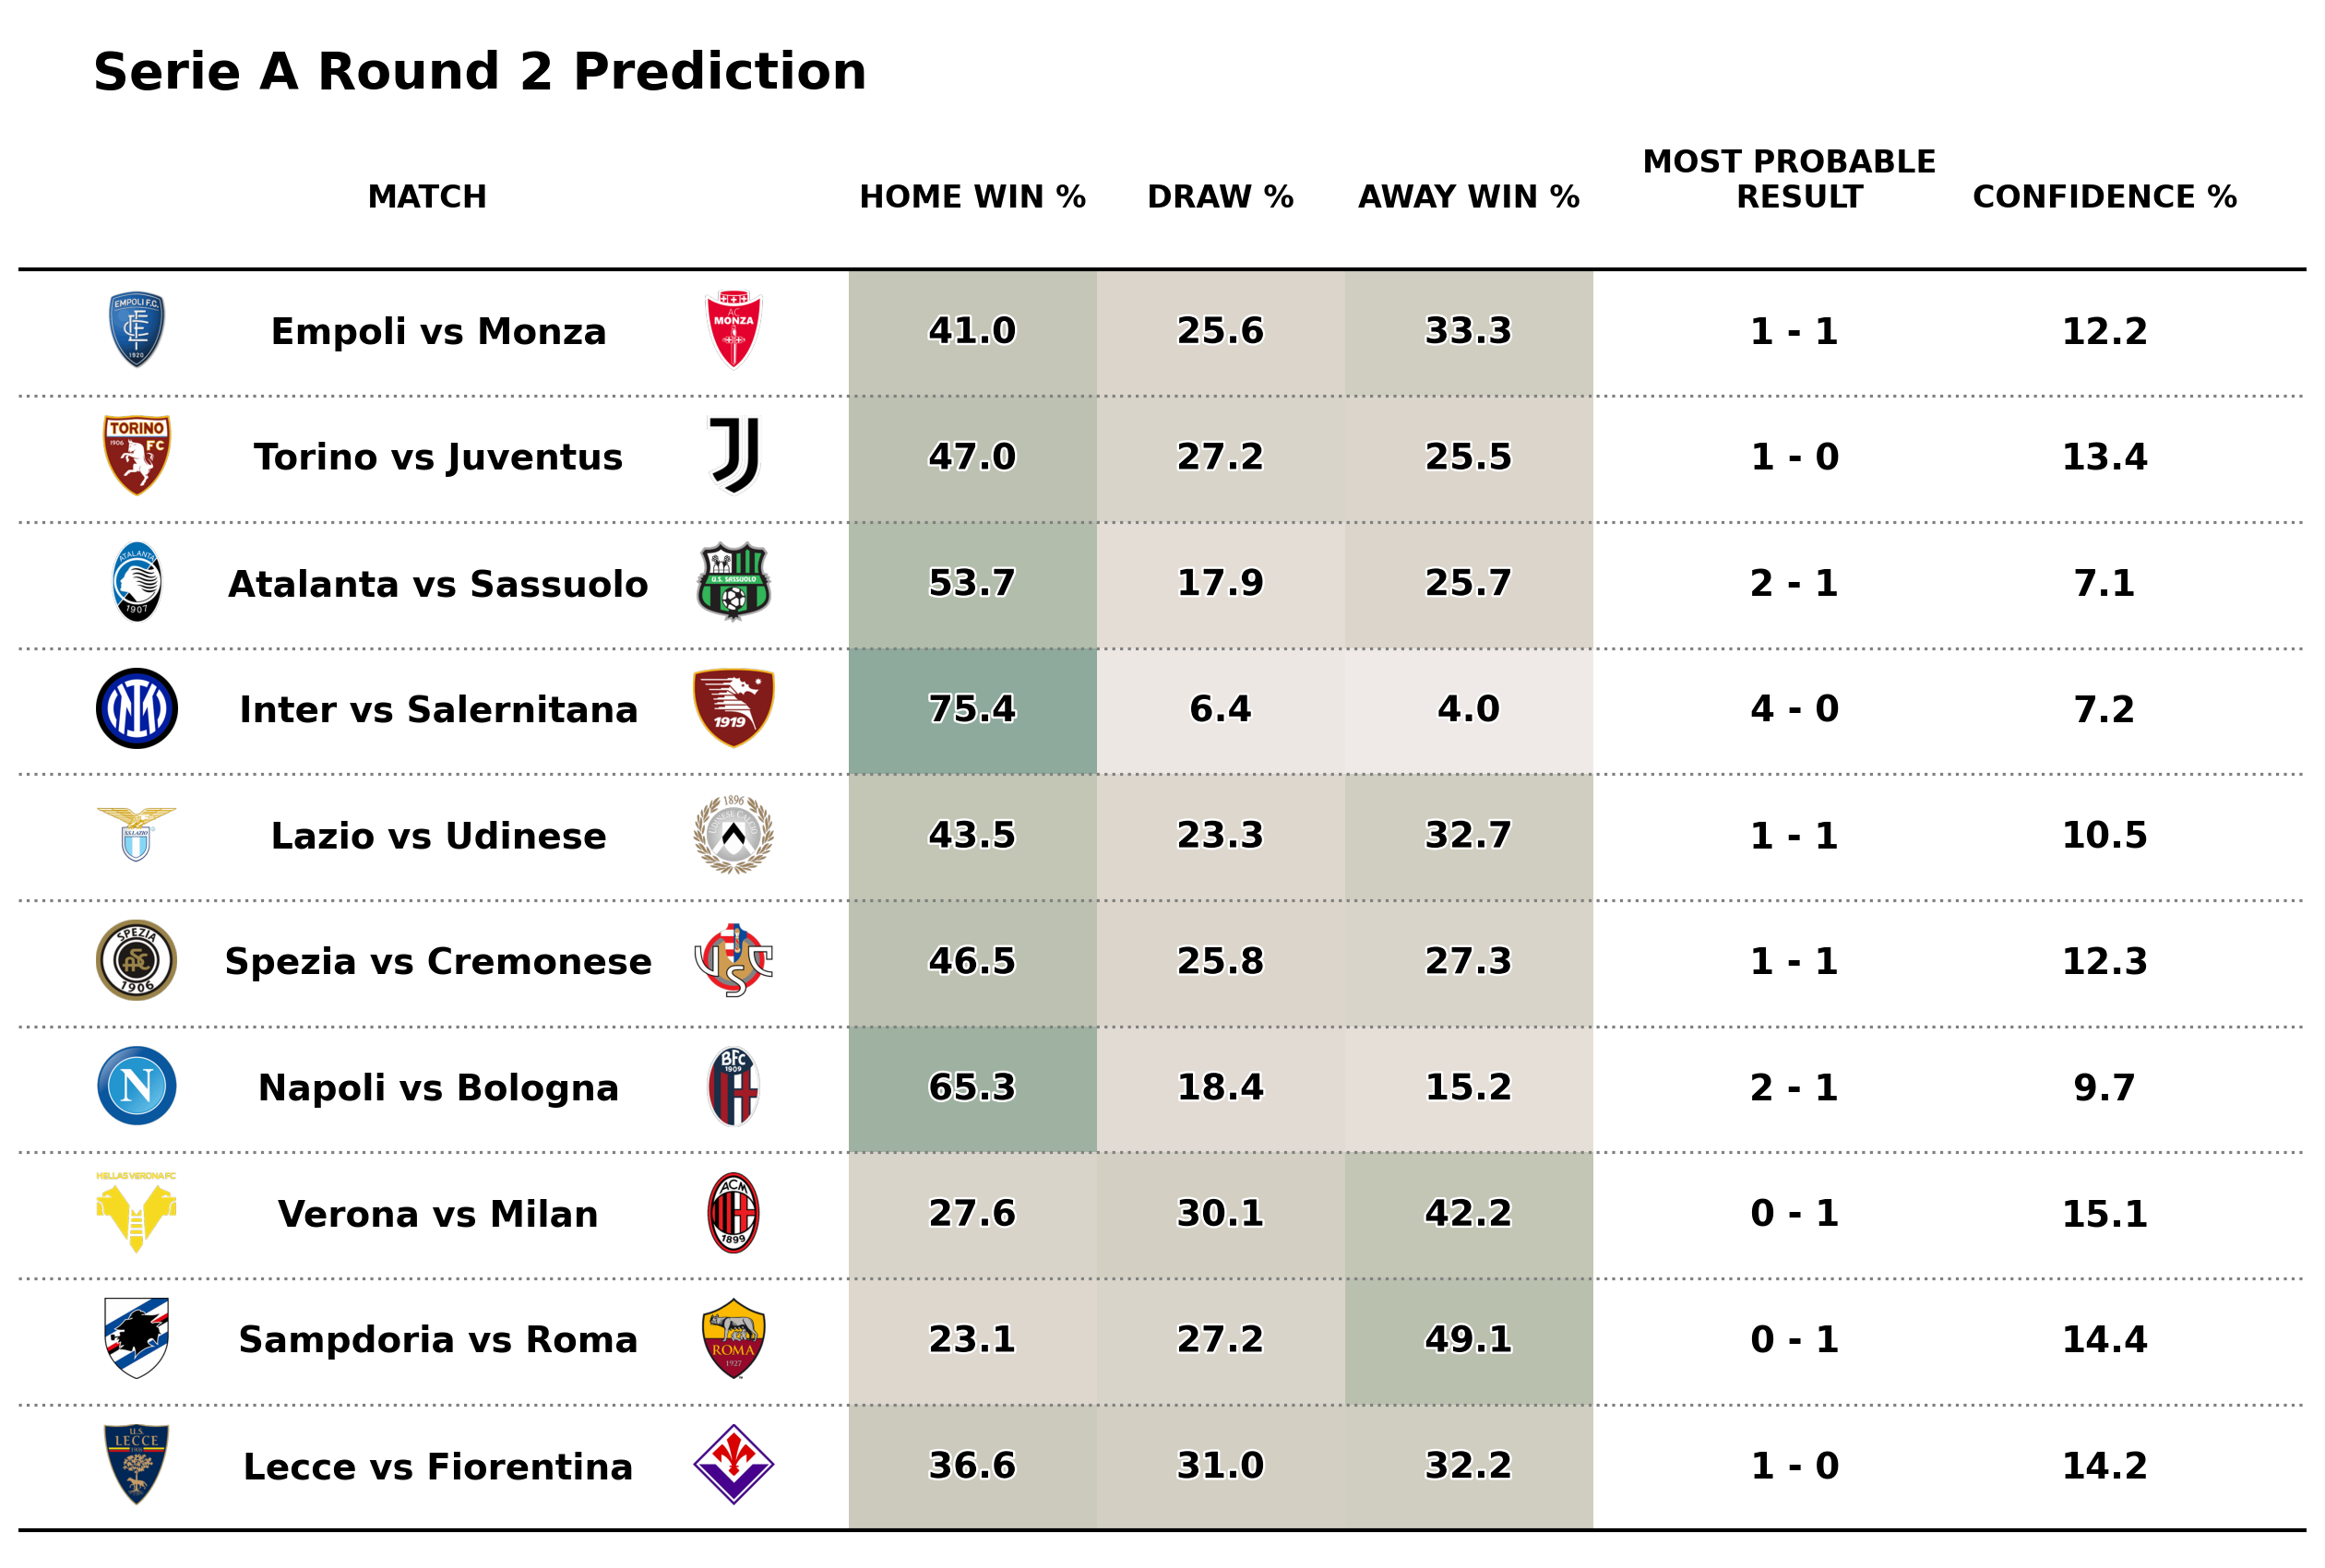

In [7]:
fig = plt.figure(figsize=(16, 11), dpi = 200)
ax = plt.subplot(111, facecolor = "#EFE9E6")

ncols = 14 
nrows = 10

ax.set_xlim(0, ncols + .75)
ax.set_ylim(-.15, nrows + 2)

# --- Define URL and helper functions to add logos
fotmob_url = 'https://images.fotmob.com/image_resources/logo/teamlogo/'
DC_to_FC = ax.transData.transform
FC_to_NFC = fig.transFigure.inverted().transform
# Native data to normalized data coordinates
DC_to_NFC = lambda x: FC_to_NFC(DC_to_FC(x))

# -- The CMAP fot the gradient
cmap = cm.get_cmap('SOC')

for y in range(nrows):
    # - Home logo
    x = 0
    team_id = df2['HOME ID'].iloc[y]
    ax_coords = DC_to_NFC([x + .5, y + .2])
    logo_ax = fig.add_axes([ax_coords[0], ax_coords[1], 0.04, 0.04], anchor = "W")
    club_icon = Image.open(urllib.request.urlopen(f"{fotmob_url}{team_id:.0f}.png"))
    logo_ax.imshow(club_icon)
    logo_ax.axis("off")
    # - Away logo
    x = 5 
    team_id = df2['AWAY ID'].iloc[y]
    ax_coords = DC_to_NFC([x - .65, y + .2])
    logo_ax = fig.add_axes([ax_coords[0], ax_coords[1], 0.04, 0.04], anchor = "W")
    club_icon = Image.open(urllib.request.urlopen(f"{fotmob_url}{team_id:.0f}.png"))
    logo_ax.imshow(club_icon)
    logo_ax.axis("off")
    
    # - Fixture result
    x = 2.75
    home_name = df2['HOME TEAM'].iloc[y]
    away_name = df2['AWAY TEAM'].iloc[y]
    label_ = f'{home_name} vs {away_name} '
    ax.annotate(
        xy=(x,y + 0.5),
        text=label_,
        ha='center',
        va='center',
        size=14,
        weight='bold'
    )
    
    x = 6.15
    home_win = df2['HOME WIN %'].iloc[y]
    label_ = f'{home_win}'
    text_ = ax.annotate(
            xy=(x,y + 0.5),
            text=label_,
            ha='center',
            va='center',
            size=14,
            weight='bold'
    )
    text_.set_path_effects(
        [path_effects.Stroke(linewidth=1.75, foreground="white"), path_effects.Normal()])
    
    x = 7.75
    draw = df2['DRAW %'].iloc[y]
    label_ = f'{draw}'
    text_ = ax.annotate(
            xy=(x,y + 0.5),
            text=label_,
            ha='center',
            va='center',
            size=14,
            weight='bold'
    )
    text_.set_path_effects(
        [path_effects.Stroke(linewidth=1.75, foreground="white"), path_effects.Normal()])

    x = 9.35
    away_win = df2['AWAY WIN %'].iloc[y]
    label_ = f'{away_win}'
    text_ = ax.annotate(
            xy=(x,y + 0.5),
            text=label_,
            ha='center',
            va='center',
            size=14,
            weight='bold'
    )
    text_.set_path_effects(
        [path_effects.Stroke(linewidth=1.75, foreground="white"), path_effects.Normal()])    
    
    x = 11.45
    result = df2['MOST PROBABLE RESULT'].iloc[y]
    label_ = f'{result}'
    ax.annotate(
        xy=(x,y + 0.5),
        text=label_,
        ha='center',
        va='center',
        size=14,
        weight='bold'
    )
    
    x = 13.45
    prob = df2['CONFIDENCE %'].iloc[y]
    label_ = f'{prob}'
    ax.annotate(
        xy=(x,y + 0.5),
        text=label_,
        ha='center',
        va='center',
        size=14,
        weight='bold'
    )
    
    # -- Adding the colors
    # -- We subtract and add .575 beacause the width of our colum in 1.15, 1/15/2 = .575
    x = 6.15
    ax.fill_between(
        x=[(x - .8), (x + .8)],
        y1=y,
        y2=y + 1,
        color=cmap(float(home_win)/100),
        zorder=2,
        ec="None",
        alpha=0.75
    )
    x = 7.75
    ax.fill_between(
        x=[(x - .8), (x + .8)],
        y1=y,
        y2=y + 1,
        color=cmap(float(draw)/100),
        zorder=2,
        ec="None",
        alpha=0.75
    )
    x = 9.35
    ax.fill_between(
        x=[(x - .8), (x + .8)],
        y1=y,
        y2=y + 1,
        color=cmap(float(away_win)/100),
        zorder=2,
        ec="None",
        alpha=0.75
    )
    
# Table borders
ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [nrows, nrows], lw = 1.5, color = "black", marker = "", zorder = 4)
ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [0, 0], lw = 1.5, color = "black", marker = "", zorder = 4)
for x in range(nrows):
    if x == 0:
        continue
    ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [x, x], lw = 1.15, color = "gray", ls = ":", zorder = 3 , marker = "")
    
ax.annotate(
    xy = (2.25, nrows + .5),
    text = "MATCH",
    weight = "bold",
    ha = "left",
    size = 12
)

ax.annotate(
    xy = (6.15, nrows + .5),
    text = 'HOME WIN %',
    weight = "bold",
    ha = "center",
    size = 12
)
ax.annotate(
    xy = (7.75, nrows + .5),
    text = 'DRAW %',
    weight = "bold",
    ha = "center",
    size = 12
)
ax.annotate(
    xy = (9.35, nrows + .5),
    text = 'AWAY WIN %',
    weight = "bold",
    ha = "center",
    size = 12
)
ax.annotate(
    xy = (11.45, nrows + .5),
    text = 'MOST PROBABLE \n RESULT',
    weight = "bold",
    ha = "center",
    size = 12
)

ax.annotate(
    xy = (13.45, nrows + .5),
    text = 'CONFIDENCE %',
    weight = "bold",
    ha = "center",
    size = 12
)

ax.set_axis_off()

fig_text(
    x = 0.15, y = 0.84, 
    s = "Serie A Round 2 Prediction",
    va = "bottom", ha = "left",
    fontsize = 20, color = "black", font = "DM Sans", weight = "bold"
)

In [9]:
# team_home="Torino", home_id=9804, team_away="Torino", away_id=9804
# team_home="Lazio", home_id=8543, team_away="Lazio", away_id=8543
# team_home="Udinese", home_id=8600, team_away="Udinese", away_id=8600
# team_home="Salernitana", home_id=6480, team_away="Salernitana", away_id=6480
# team_home="Inter", home_id=8636, team_away="Inter", away_id=8636
# team_home="Spezia", home_id=9881, team_away="Spezia", away_id=9881
# team_home="Sassuolo", home_id=7943, team_away="Sassuolo", away_id=7943 
# team_home="Lecce", home_id=9888, team_away="Lecce", away_id=9888
# team_home="Napoli", home_id=9875, team_away="Napoli", away_id=9875
# team_home="Monza", home_id=6504, team_away="Monza", away_id=6504
# team_home="Empoli", home_id=8534, team_away="Empoli", away_id=8534
# team_home="Fiorentina", home_id=8535, team_away="Fiorentina", away_id=8535
# team_home="Bologna", home_id=9857, team_away="Bologna", away_id=9857
# team_home="Verona", home_id=9876, team_away="Verona", away_id=9876
# team_home="Atalanta", home_id=8524, team_away="Atalanta", away_id=8524
# team_home="Milan", home_id=8564, team_away="Milan", away_id=8564
# team_home="Roma", home_id= 8686, team_away="Roma", away_id= 8686
# team_home="Cremonese", home_id=7801, team_away="Cremonese", away_id=7801 
# team_home="Sampdoria", home_id=9882, team_away="Sampdoria", away_id=9882
# team_home="Juventus", home_id=9885, team_away="Juventus", away_id=9885